In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cleaning_utils import clean_dataset2

In [21]:
raw_df = pd.read_csv('OML_4G_DATA_OSS.csv')
df = clean_dataset2(raw_df)

df.head()

,Time,eNodeB_Function_Name,Cell_Name,Frequency_band,Avg_DL_User_Thrput_kbps,Avg_DL_Traffic_Active_User,Date,Hour
0,2024-05-27,1288_KKO_KATI_4G,1288_KKO_KATI_1_L800,20,7543.2661,2.6076,2024-05-27,0
1,2024-05-27,1324_BKO_SOGONIKO_4G,1324_BKO_SOGONIKO_3_L800,20,9686.8516,0.8624,2024-05-27,0
2,2024-05-27,1560_BKO_SENOU-MEDINE_4G,1560_BKO_SENOU-MEDINE_2_L1800,3,12827.9154,1.8092,2024-05-27,0
3,2024-05-27,1605_BKO_NIARELAMosque_4G,1605_BKO_NIARELAMosque_1_L700,28,0.0000,0.0000,2024-05-27,0
4,2024-05-27,1634_BKO_DOUMANZANA_4G,1634_BKO_DOUMANZANA_3_L1800,3,18474.4263,0.7931,2024-05-27,0


## Traffic Active User Modeling

In [23]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_and_plot_prophet(df, cell_name, test_ratio=0.2, return_forecast=False):
    df_cell = df[df['Cell_Name'] == cell_name][['Date', 'Avg_DL_Traffic_Active_User']].copy()
    df_cell.rename(columns={'Date': 'ds', 'Avg_DL_Traffic_Active_User': 'y'}, inplace=True)
    df_cell = df_cell.sort_values('ds')

    # Train/test split
    split_index = int(len(df_cell) * (1 - test_ratio))
    train_df = df_cell.iloc[:split_index]
    test_df = df_cell.iloc[split_index:]

    # Prophet model
    model = Prophet()
    model.fit(train_df)

    future = model.make_future_dataframe(periods=len(test_df), freq='D')
    forecast = model.predict(future)

    # Align forecast with actual test
    forecast_test = forecast[['ds', 'yhat']].merge(test_df[['ds', 'y']], on='ds', how='inner')

    # Metrics
    mae = mean_absolute_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mean_squared_error(forecast_test['y'], forecast_test['yhat']))
    mape = np.mean(np.abs((forecast_test['y'] - forecast_test['yhat']) / forecast_test['y'])) * 100

    print(f"\nEvaluation for {cell_name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Plot: train, test, forecast
    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Train')
    plt.plot(test_df['ds'], test_df['y'], label='Test')
    plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Prophet Forecast')
    plt.title(f'Prophet Forecast vs Actual for Cell {cell_name}')
    plt.xlabel('Date')
    plt.ylabel('Avg DL Traffic Active User')
    plt.legend()
    plt.grid(True)
    plt.show()

    if return_forecast:
        return forecast_test[['ds', 'yhat']].assign(cell=cell_name)

15:01:51 - cmdstanpy - INFO - Chain [1] start processing
15:01:51 - cmdstanpy - INFO - Chain [1] done processing



Evaluation for 4262_KYS_KENIEBA_3_L800
MAE:  29.00
RMSE: 36.94
MAPE: 60.07%


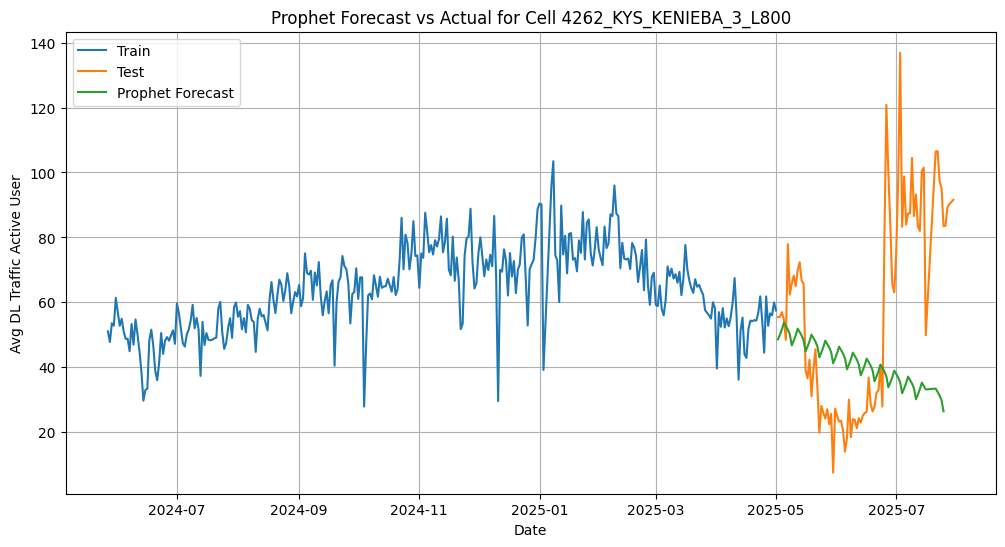

15:01:52 - cmdstanpy - INFO - Chain [1] start processing
15:01:52 - cmdstanpy - INFO - Chain [1] done processing



Evaluation for 5001_KKO_DEGUEDOUMOU_3_L1800
MAE:  59.21
RMSE: 66.12
MAPE: 200.37%


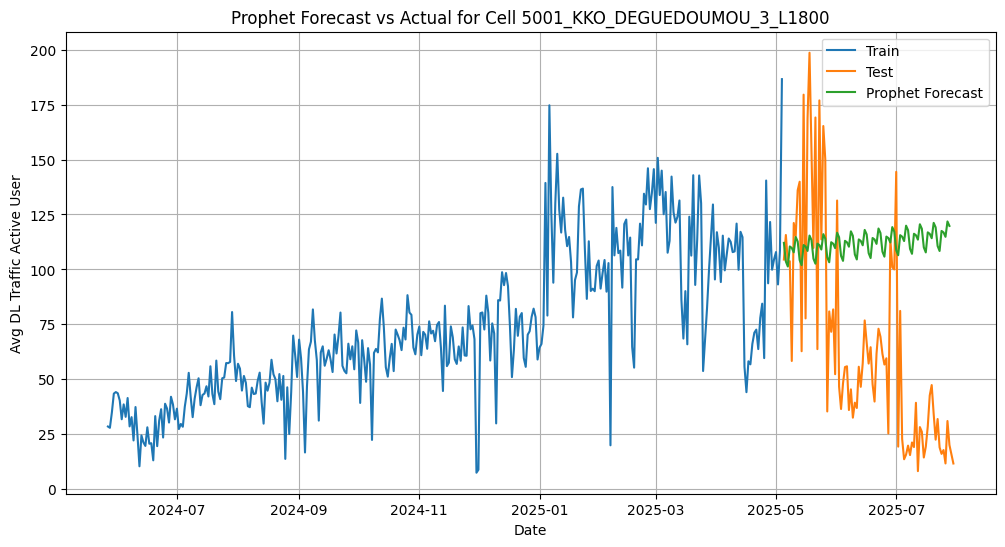

15:01:53 - cmdstanpy - INFO - Chain [1] start processing
15:01:53 - cmdstanpy - INFO - Chain [1] done processing



Evaluation for 0446_KYS_KENIEBA_3_L2600
MAE:  32.90
RMSE: 46.48
MAPE: 55.93%


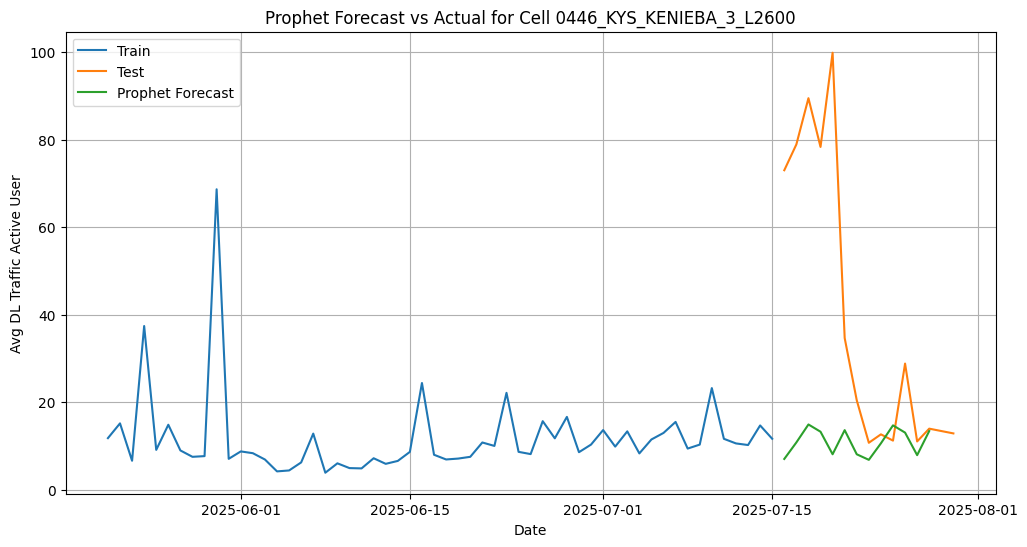

In [26]:
# Selected cells
cells = [
    '4262_KYS_KENIEBA_3_L800',
    '5001_KKO_DEGUEDOUMOU_3_L1800',
    '0446_KYS_KENIEBA_3_L2600'
]

# Run forecast and collect predictions
all_forecasts = []

for cell in cells:
    forecast_df = evaluate_and_plot_prophet(df, cell, return_forecast=True)
    all_forecasts.append(forecast_df)

### Enhancing with Full Log + Multiplicative Function

In [27]:
def evaluate_and_plot_prophet_log(df, cell_name, test_ratio=0.2, return_forecast=False):
    df_cell = df[df['Cell_Name'] == cell_name][['Date', 'Avg_DL_Traffic_Active_User']].copy()
    df_cell.rename(columns={'Date': 'ds', 'Avg_DL_Traffic_Active_User': 'y'}, inplace=True)
    df_cell = df_cell.sort_values('ds')

    # Apply log transform
    df_cell['y'] = np.log1p(df_cell['y'])  # log(1 + y) to handle 0s

    # Train/test split
    split_index = int(len(df_cell) * (1 - test_ratio))
    train_df = df_cell.iloc[:split_index]
    test_df = df_cell.iloc[split_index:]

    # Prophet model with multiplicative seasonality
    model = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, weekly_seasonality=True)
    model.fit(train_df)

    # Forecast
    future = model.make_future_dataframe(periods=len(test_df), freq='D')
    forecast = model.predict(future)

    # Inverse transform forecast
    forecast['yhat'] = np.expm1(forecast['yhat'])  # inverse of log1p

    # Align forecast with actual test data
    actual_test = df[df['Cell_Name'] == cell_name][['Date', 'Avg_DL_Traffic_Active_User']].copy()
    actual_test.rename(columns={'Date': 'ds', 'Avg_DL_Traffic_Active_User': 'y'}, inplace=True)
    actual_test = actual_test.sort_values('ds').iloc[split_index:].reset_index(drop=True)
    forecast_test = forecast[['ds', 'yhat']].merge(actual_test, on='ds', how='inner')

    # Evaluation
    mae = mean_absolute_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mean_squared_error(forecast_test['y'], forecast_test['yhat']))
    mape = np.mean(np.abs((forecast_test['y'] - forecast_test['yhat']) / forecast_test['y'])) * 100

    print(f"\nLog + Mult Forecast Evaluation for {cell_name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(df_cell.iloc[:split_index]['ds'], np.expm1(train_df['y']), label='Train')
    plt.plot(actual_test['ds'], actual_test['y'], label='Test')
    plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Prophet Forecast')
    plt.title(f'Enhanced Prophet (Log + Multiplicative) for {cell_name}')
    plt.xlabel('Date')
    plt.ylabel('Avg DL Traffic Active User')
    plt.legend()
    plt.grid(True)
    plt.show()

    if return_forecast:
        return forecast_test[['ds', 'yhat']].assign(cell=cell_name)

15:02:51 - cmdstanpy - INFO - Chain [1] start processing
15:02:51 - cmdstanpy - INFO - Chain [1] done processing



Log + Mult Forecast Evaluation for 4262_KYS_KENIEBA_3_L800
MAE:  27.32
RMSE: 31.34
MAPE: 83.37%


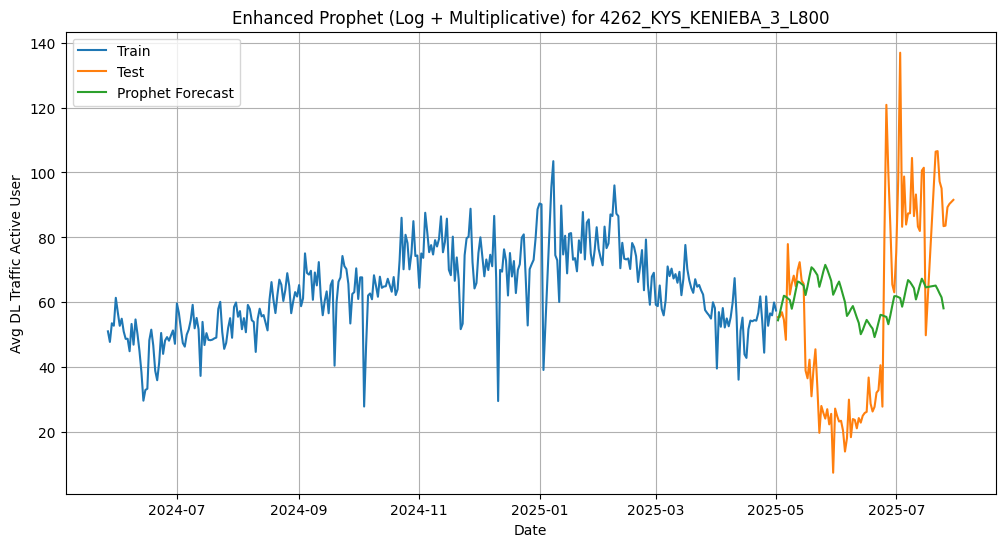

15:02:53 - cmdstanpy - INFO - Chain [1] start processing
15:02:53 - cmdstanpy - INFO - Chain [1] done processing



Log + Mult Forecast Evaluation for 5001_KKO_DEGUEDOUMOU_3_L1800
MAE:  222.07
RMSE: 246.60
MAPE: 660.57%


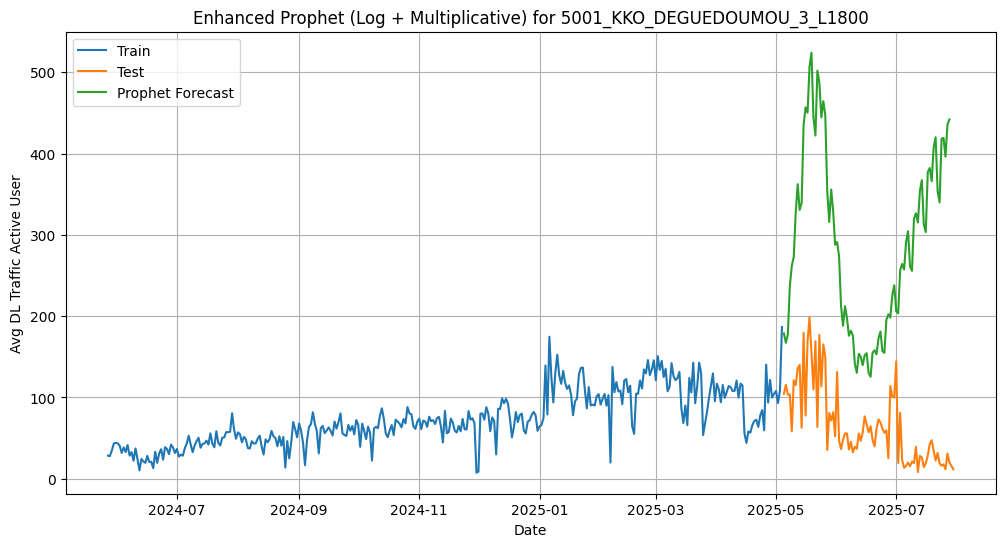

15:02:54 - cmdstanpy - INFO - Chain [1] start processing
15:02:55 - cmdstanpy - INFO - Chain [1] done processing



Log + Mult Forecast Evaluation for 0446_KYS_KENIEBA_3_L2600
MAE:  39.92
RMSE: 50.35
MAPE: 92.92%


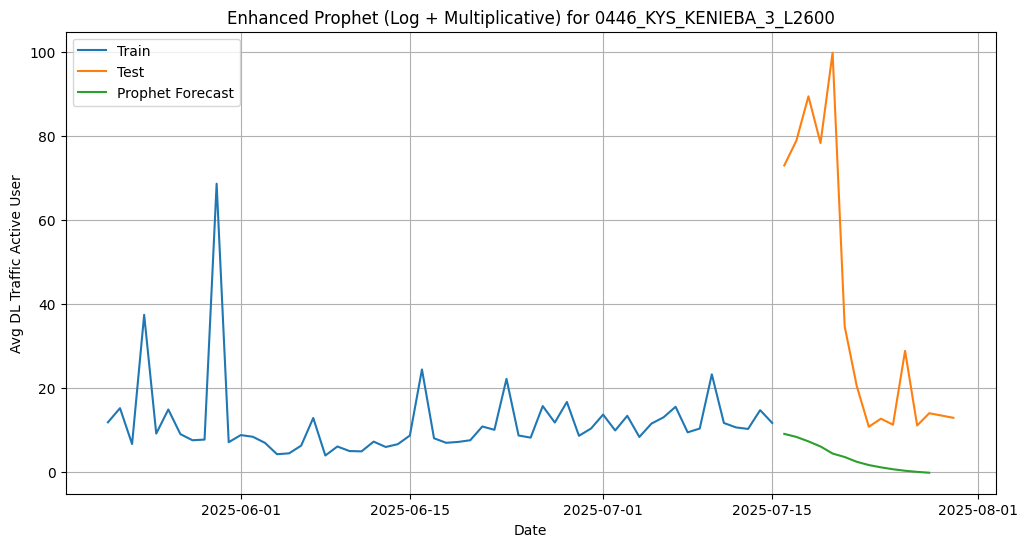

In [28]:
# Selected cells
cells = [
    '4262_KYS_KENIEBA_3_L800',
    '5001_KKO_DEGUEDOUMOU_3_L1800',
    '0446_KYS_KENIEBA_3_L2600'
]

# Run forecast and collect predictions
all_forecasts = []

for cell in cells:
    forecast_df = evaluate_and_plot_prophet_log(df, cell, return_forecast=True)
    all_forecasts.append(forecast_df)

### Enhancing with Regressor

In [29]:
def evaluate_prophet_with_regressor(df, cell_name, test_ratio=0.2, return_forecast=False):
    # Filter the cell and keep both KPIs
    df_cell = df[df['Cell_Name'] == cell_name][['Date', 'Avg_DL_Traffic_Active_User', 'Avg_DL_User_Thrput_kbps']].copy()
    df_cell.rename(columns={
        'Date': 'ds',
        'Avg_DL_Traffic_Active_User': 'y',
        'Avg_DL_User_Thrput_kbps': 'throughput'
    }, inplace=True)
    df_cell = df_cell.sort_values('ds')

    # Train/test split
    split_index = int(len(df_cell) * (1 - test_ratio))
    train_df = df_cell.iloc[:split_index]
    test_df = df_cell.iloc[split_index:]

    # Prophet with regressor
    model = Prophet()
    model.add_regressor('throughput')
    model.fit(train_df)

    # Forecast: build future dataframe and include future regressor values
    future = df_cell[['ds', 'throughput']]  # reuse full dataframe (including future regressor)
    forecast = model.predict(future)

    # Align forecast with actual test set
    test_df = test_df.reset_index(drop=True)
    forecast_test = forecast[['ds', 'yhat']].merge(test_df[['ds', 'y']], on='ds', how='inner')

    # Evaluation
    mae = mean_absolute_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mean_squared_error(forecast_test['y'], forecast_test['yhat']))
    mape = np.mean(np.abs((forecast_test['y'] - forecast_test['yhat']) / forecast_test['y'])) * 100

    print(f"\nProphet + Regressor Evaluation for {cell_name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Train')
    plt.plot(test_df['ds'], test_df['y'], label='Test')
    plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Prophet + Regressor Forecast')
    plt.title(f'Prophet with Throughput Regressor — {cell_name}')
    plt.xlabel('Date')
    plt.ylabel('Avg DL Traffic Active User')
    plt.legend()
    plt.grid(True)
    plt.show()

    if return_forecast:
        return forecast_test[['ds', 'yhat']].assign(cell=cell_name)

15:03:43 - cmdstanpy - INFO - Chain [1] start processing
15:03:43 - cmdstanpy - INFO - Chain [1] done processing



Prophet + Regressor Evaluation for 4262_KYS_KENIEBA_3_L800
MAE:  49.00
RMSE: 55.86
MAPE: 107.82%


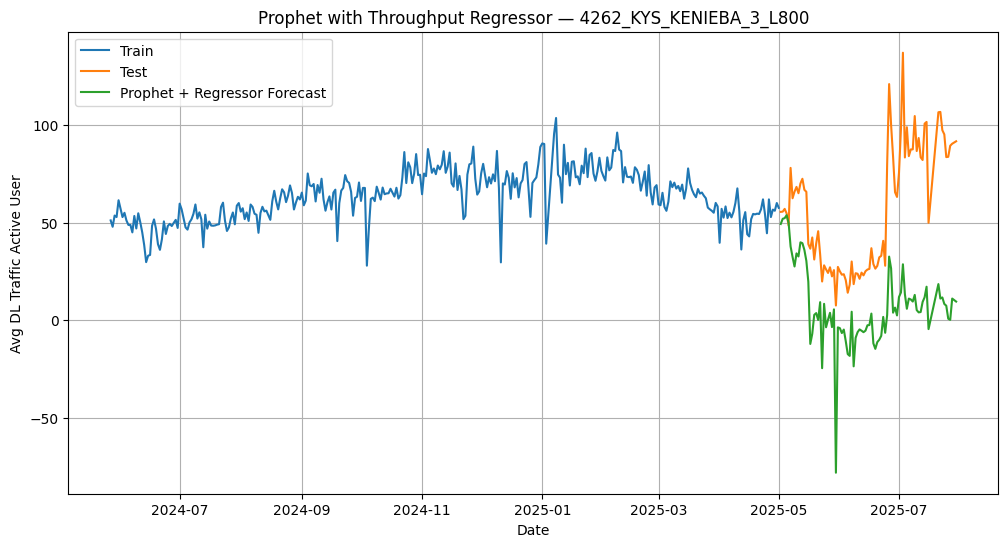

15:03:44 - cmdstanpy - INFO - Chain [1] start processing
15:03:44 - cmdstanpy - INFO - Chain [1] done processing



Prophet + Regressor Evaluation for 5001_KKO_DEGUEDOUMOU_3_L1800
MAE:  49.28
RMSE: 57.51
MAPE: 176.41%


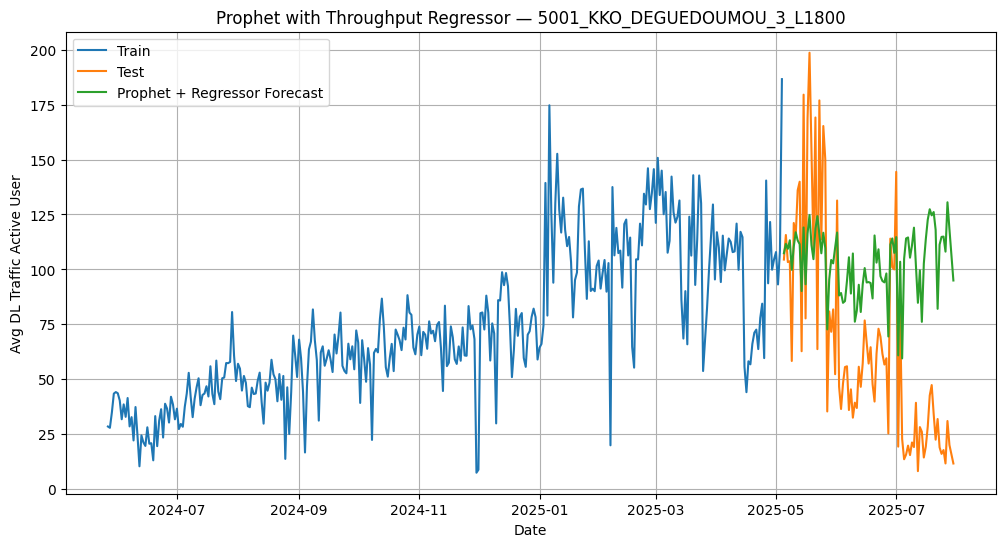

15:03:45 - cmdstanpy - INFO - Chain [1] start processing
15:03:45 - cmdstanpy - INFO - Chain [1] done processing



Prophet + Regressor Evaluation for 0446_KYS_KENIEBA_3_L2600
MAE:  27.08
RMSE: 38.80
MAPE: 50.13%


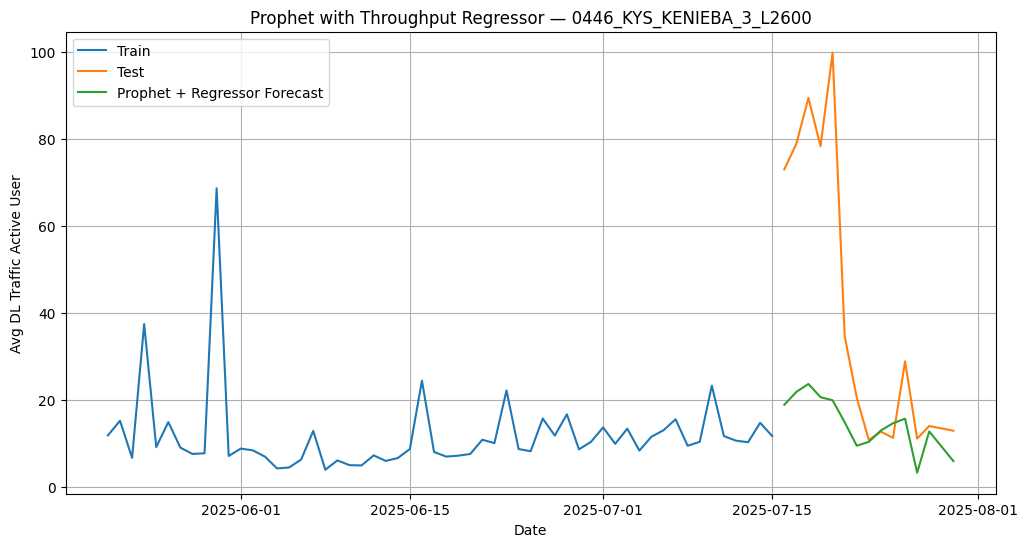

In [30]:
evaluate_prophet_with_regressor(df, '4262_KYS_KENIEBA_3_L800')
evaluate_prophet_with_regressor(df, '5001_KKO_DEGUEDOUMOU_3_L1800')
evaluate_prophet_with_regressor(df, '0446_KYS_KENIEBA_3_L2600')

## Modeling Throughput

In [31]:
def evaluate_and_plot_prophet_thrpt(df, cell_name, test_ratio=0.2, return_forecast=False):
    df_cell = df[df['Cell_Name'] == cell_name][['Date', 'Avg_DL_User_Thrput_kbps']].copy()
    df_cell.rename(columns={'Date': 'ds', 'Avg_DL_User_Thrput_kbps': 'y'}, inplace=True)
    df_cell = df_cell.sort_values('ds')

    # Train/test split
    split_index = int(len(df_cell) * (1 - test_ratio))
    train_df = df_cell.iloc[:split_index]
    test_df = df_cell.iloc[split_index:]

    # Prophet model
    model = Prophet()
    model.fit(train_df)

    future = model.make_future_dataframe(periods=len(test_df), freq='D')
    forecast = model.predict(future)

    # Align forecast with actual test
    forecast_test = forecast[['ds', 'yhat']].merge(test_df[['ds', 'y']], on='ds', how='inner')

    # Metrics
    mae = mean_absolute_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mean_squared_error(forecast_test['y'], forecast_test['yhat']))
    mape = np.mean(np.abs((forecast_test['y'] - forecast_test['yhat']) / forecast_test['y'])) * 100

    print(f"\nEvaluation for {cell_name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Plot: train, test, forecast
    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Train')
    plt.plot(test_df['ds'], test_df['y'], label='Test')
    plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Prophet Forecast')
    plt.title(f'Prophet Forecast vs Actual for Cell {cell_name}')
    plt.xlabel('Date')
    plt.ylabel('Avg DL User Throughput (kbps)')
    plt.legend()
    plt.grid(True)
    plt.show()

    if return_forecast:
        return forecast_test[['ds', 'yhat']].assign(cell=cell_name)

15:04:27 - cmdstanpy - INFO - Chain [1] start processing
15:04:27 - cmdstanpy - INFO - Chain [1] done processing



Evaluation for 4262_KYS_KENIEBA_3_L800
MAE:  993.84
RMSE: 1140.95
MAPE: 60.79%


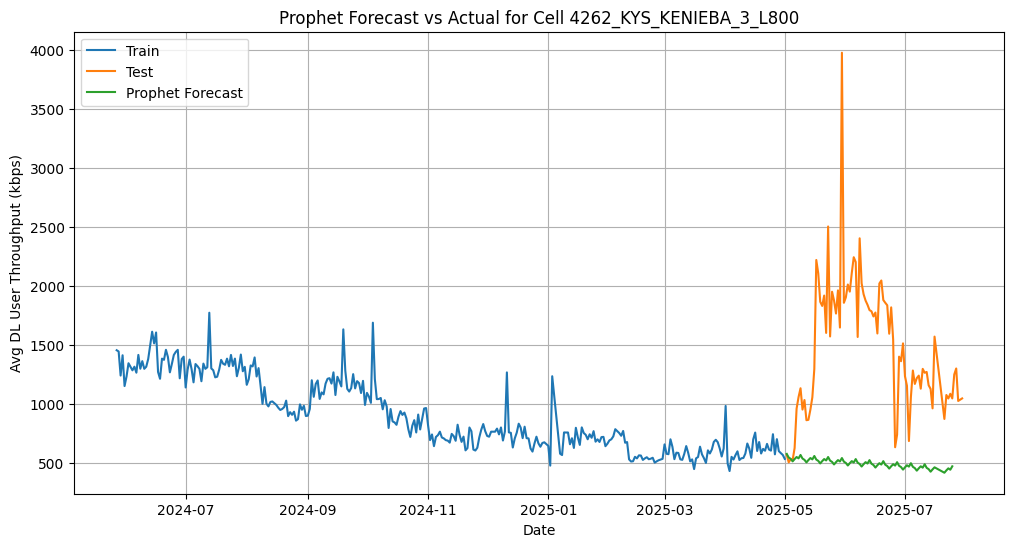

15:04:28 - cmdstanpy - INFO - Chain [1] start processing
15:04:28 - cmdstanpy - INFO - Chain [1] done processing



Evaluation for 5001_KKO_DEGUEDOUMOU_3_L1800
MAE:  904.49
RMSE: 1225.32
MAPE: 24.27%


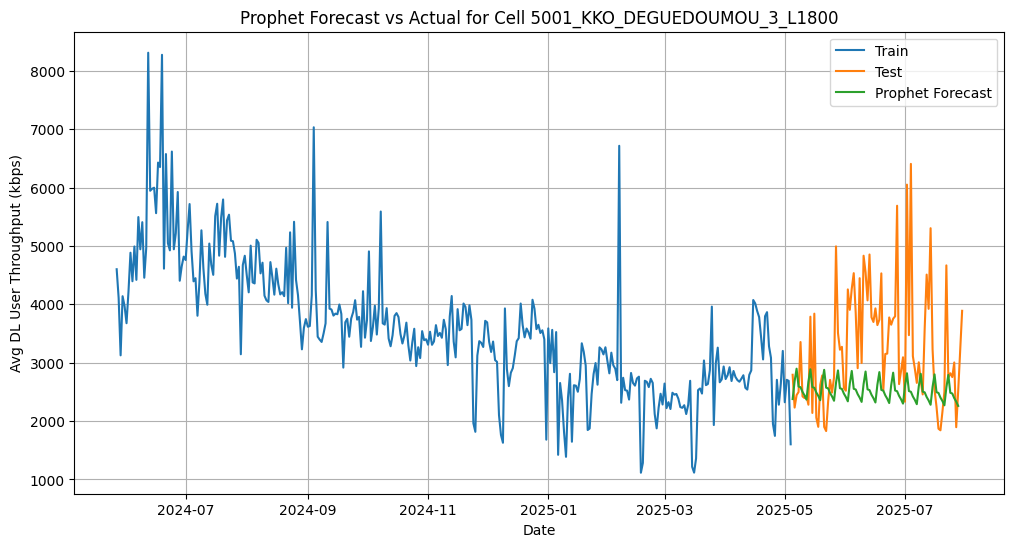

15:04:29 - cmdstanpy - INFO - Chain [1] start processing
15:04:29 - cmdstanpy - INFO - Chain [1] done processing



Evaluation for 0446_KYS_KENIEBA_3_L2600
MAE:  1246.83
RMSE: 1611.69
MAPE: 72.82%


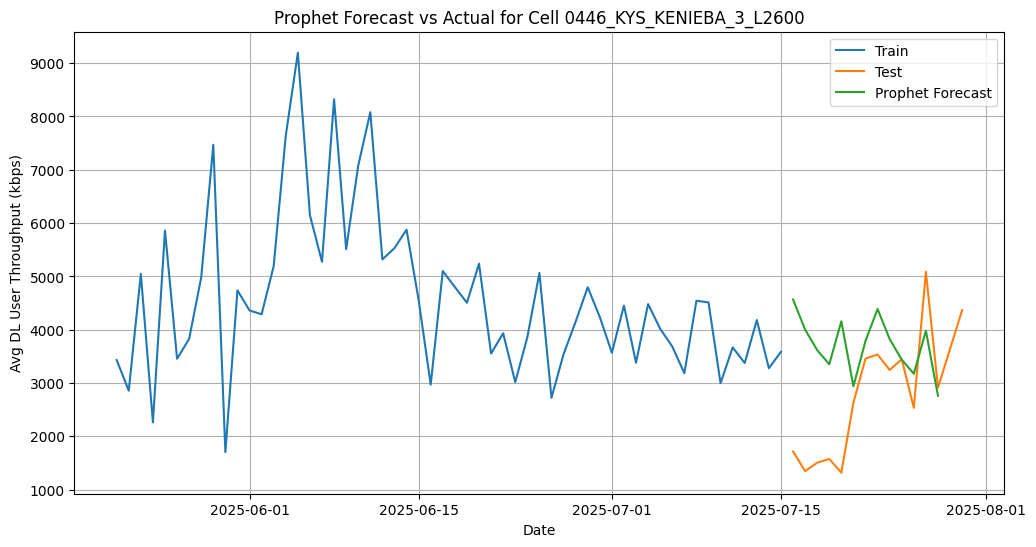

In [32]:
# Selected cells
cells = [
    '4262_KYS_KENIEBA_3_L800',
    '5001_KKO_DEGUEDOUMOU_3_L1800',
    '0446_KYS_KENIEBA_3_L2600'
]

# Run forecast and collect predictions
all_forecasts = []

for cell in cells:
    forecast_df = evaluate_and_plot_prophet_thrpt(df, cell, return_forecast=True)
    all_forecasts.append(forecast_df)

### Enhancing with Full Log + Multiplicative Function

In [33]:
def evaluate_and_plot_prophet_log_thrpt(df, cell_name, test_ratio=0.2, return_forecast=False):
    df_cell = df[df['Cell_Name'] == cell_name][['Date', 'Avg_DL_User_Thrput_kbps']].copy()
    df_cell.rename(columns={'Date': 'ds', 'Avg_DL_User_Thrput_kbps': 'y'}, inplace=True)
    df_cell = df_cell.sort_values('ds')

    # Apply log transform
    df_cell['y'] = np.log1p(df_cell['y'])  # log(1 + y) to handle 0s

    # Train/test split
    split_index = int(len(df_cell) * (1 - test_ratio))
    train_df = df_cell.iloc[:split_index]
    test_df = df_cell.iloc[split_index:]

    # Prophet model with multiplicative seasonality
    model = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True, weekly_seasonality=True)
    model.fit(train_df)

    # Forecast
    future = model.make_future_dataframe(periods=len(test_df), freq='D')
    forecast = model.predict(future)

    # Inverse transform forecast
    forecast['yhat'] = np.expm1(forecast['yhat'])  # inverse of log1p

    # Align forecast with actual test data
    actual_test = df[df['Cell_Name'] == cell_name][['Date', 'Avg_DL_User_Thrput_kbps']].copy()
    actual_test.rename(columns={'Date': 'ds', 'Avg_DL_User_Thrput_kbps': 'y'}, inplace=True)
    actual_test = actual_test.sort_values('ds').iloc[split_index:].reset_index(drop=True)
    forecast_test = forecast[['ds', 'yhat']].merge(actual_test, on='ds', how='inner')

    # Evaluation
    mae = mean_absolute_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mean_squared_error(forecast_test['y'], forecast_test['yhat']))
    mape = np.mean(np.abs((forecast_test['y'] - forecast_test['yhat']) / forecast_test['y'])) * 100

    print(f"\nLog + Mult Forecast Evaluation for {cell_name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(df_cell.iloc[:split_index]['ds'], np.expm1(train_df['y']), label='Train')
    plt.plot(actual_test['ds'], actual_test['y'], label='Test')
    plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Prophet Forecast')
    plt.title(f'Enhanced Prophet (Log + Multiplicative) for {cell_name}')
    plt.xlabel('Date')
    plt.ylabel('Avg DL User Throughput (kbps)')
    plt.legend()
    plt.grid(True)
    plt.show()

    if return_forecast:
        return forecast_test[['ds', 'yhat']].assign(cell=cell_name)

15:05:13 - cmdstanpy - INFO - Chain [1] start processing
15:05:13 - cmdstanpy - INFO - Chain [1] done processing



Log + Mult Forecast Evaluation for 4262_KYS_KENIEBA_3_L800
MAE:  1252.92
RMSE: 1395.78
MAPE: 78.98%


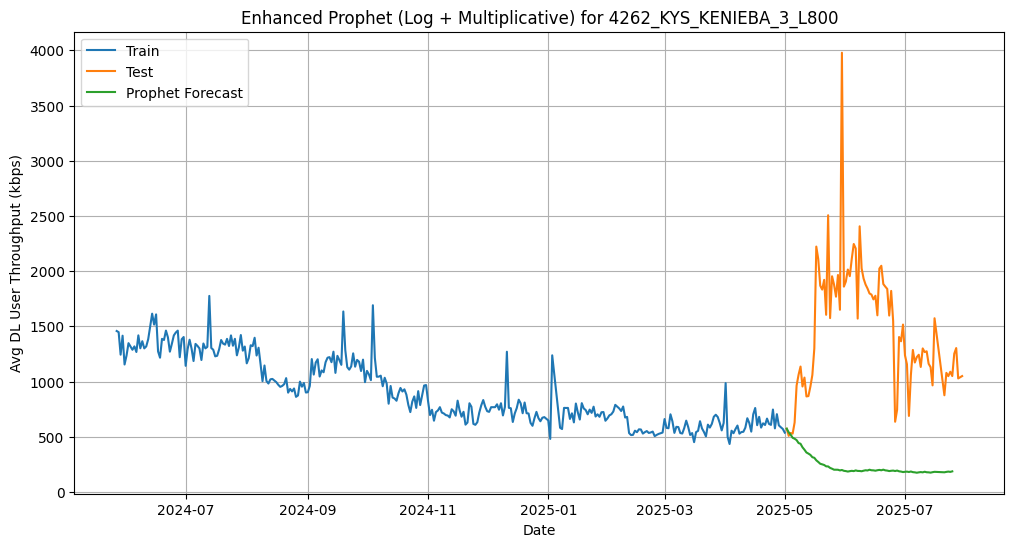

15:05:14 - cmdstanpy - INFO - Chain [1] start processing
15:05:14 - cmdstanpy - INFO - Chain [1] done processing



Log + Mult Forecast Evaluation for 5001_KKO_DEGUEDOUMOU_3_L1800
MAE:  1465.50
RMSE: 1739.87
MAPE: 41.13%


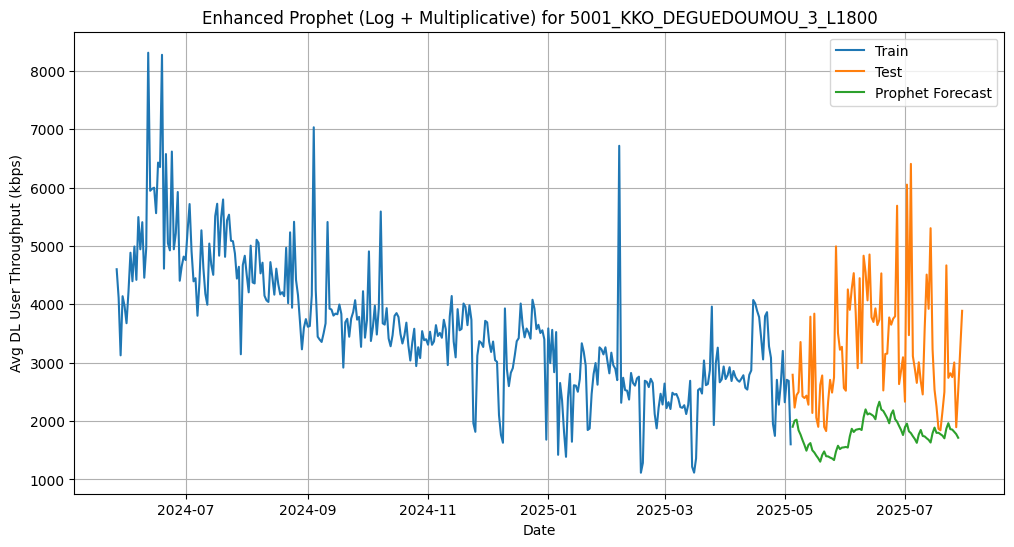

15:05:16 - cmdstanpy - INFO - Chain [1] start processing
15:05:16 - cmdstanpy - INFO - Chain [1] done processing



Log + Mult Forecast Evaluation for 0446_KYS_KENIEBA_3_L2600
MAE:  2260.18
RMSE: 2631.19
MAPE: 79.28%


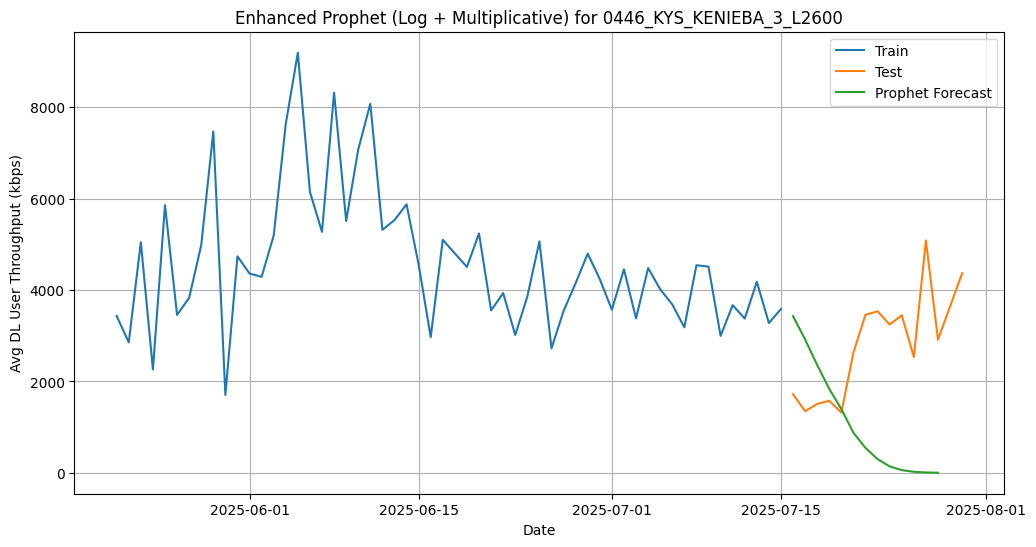

In [34]:
# Selected cells
cells = [
    '4262_KYS_KENIEBA_3_L800',
    '5001_KKO_DEGUEDOUMOU_3_L1800',
    '0446_KYS_KENIEBA_3_L2600'
]

# Run forecast and collect predictions
all_forecasts = []

for cell in cells:
    forecast_df = evaluate_and_plot_prophet_log_thrpt(df, cell, return_forecast=True)
    all_forecasts.append(forecast_df)

### Enhancing with Regressor

In [35]:
def evaluate_prophet_with_regressor_thrpt(df, cell_name, test_ratio=0.2, return_forecast=False):
    # Filter the cell and keep both KPIs
    df_cell = df[df['Cell_Name'] == cell_name][['Date', 'Avg_DL_User_Thrput_kbps', 'Avg_DL_Traffic_Active_User']].copy()
    df_cell.rename(columns={
        'Date': 'ds',
        'Avg_DL_User_Thrput_kbps': 'y',
        'Avg_DL_Traffic_Active_User': 'users'
    }, inplace=True)
    df_cell = df_cell.sort_values('ds')

    # Train/test split
    split_index = int(len(df_cell) * (1 - test_ratio))
    train_df = df_cell.iloc[:split_index]
    test_df = df_cell.iloc[split_index:]

    # Prophet with regressor
    model = Prophet()
    model.add_regressor('users')
    model.fit(train_df)

    # Forecast: build future dataframe and include future regressor values
    future = df_cell[['ds', 'users']]  # reuse full dataframe (including future regressor)
    forecast = model.predict(future)

    # Align forecast with actual test set
    test_df = test_df.reset_index(drop=True)
    forecast_test = forecast[['ds', 'yhat']].merge(test_df[['ds', 'y']], on='ds', how='inner')

    # Evaluation
    mae = mean_absolute_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mean_squared_error(forecast_test['y'], forecast_test['yhat']))
    mape = np.mean(np.abs((forecast_test['y'] - forecast_test['yhat']) / forecast_test['y'])) * 100

    print(f"\nProphet + Regressor Evaluation for {cell_name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Train')
    plt.plot(test_df['ds'], test_df['y'], label='Test')
    plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Prophet + Regressor Forecast')
    plt.title(f'Prophet with Users Regressor — {cell_name}')
    plt.xlabel('Date')
    plt.ylabel('Avg DL User Throughput (kbps)')
    plt.legend()
    plt.grid(True)
    plt.show()

    if return_forecast:
        return forecast_test[['ds', 'yhat']].assign(cell=cell_name)

15:05:50 - cmdstanpy - INFO - Chain [1] start processing
15:05:50 - cmdstanpy - INFO - Chain [1] done processing



Prophet + Regressor Evaluation for 4262_KYS_KENIEBA_3_L800
MAE:  1017.21
RMSE: 1100.33
MAPE: 68.61%


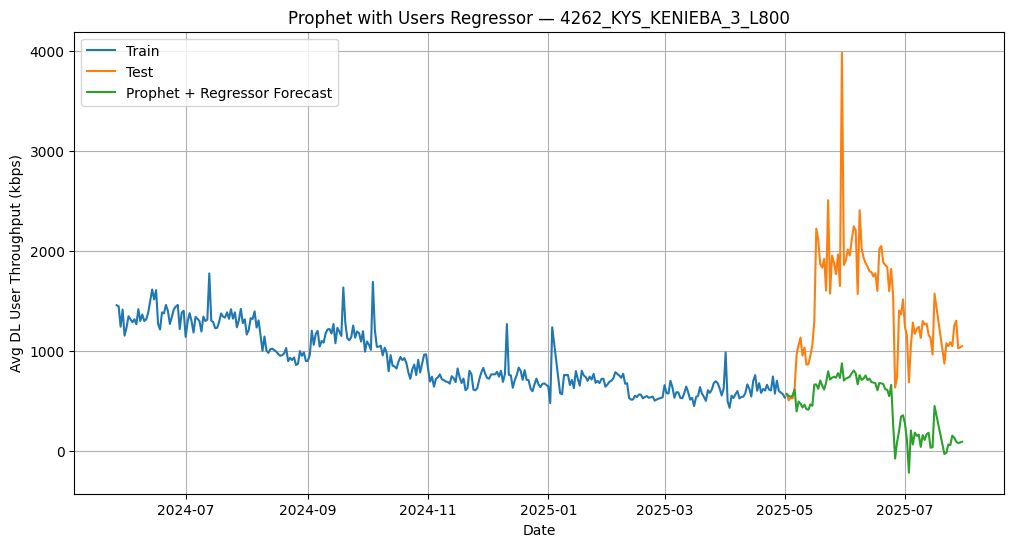

15:05:51 - cmdstanpy - INFO - Chain [1] start processing
15:05:51 - cmdstanpy - INFO - Chain [1] done processing



Prophet + Regressor Evaluation for 5001_KKO_DEGUEDOUMOU_3_L1800
MAE:  783.98
RMSE: 963.59
MAPE: 26.96%


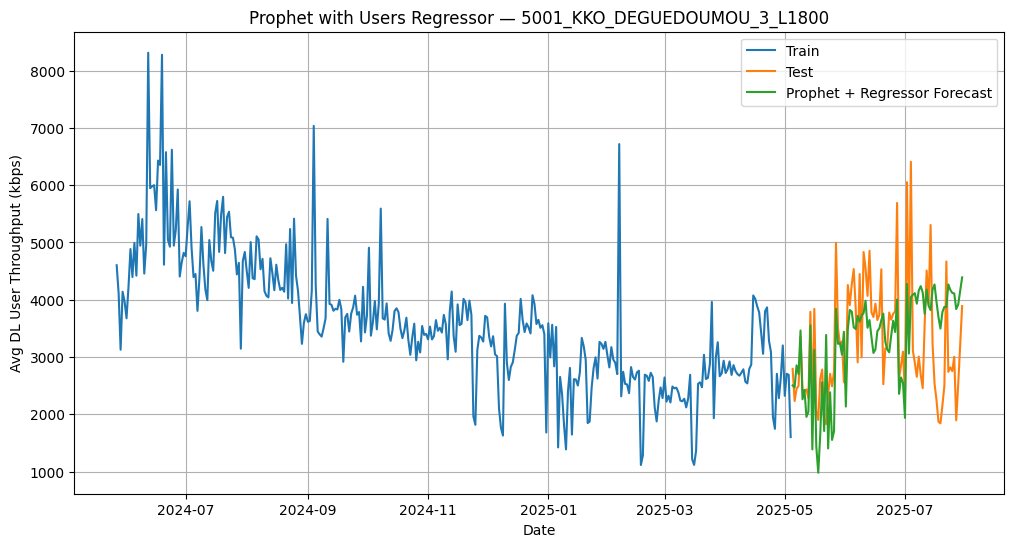

15:05:52 - cmdstanpy - INFO - Chain [1] start processing
15:05:53 - cmdstanpy - INFO - Chain [1] done processing



Prophet + Regressor Evaluation for 0446_KYS_KENIEBA_3_L2600
MAE:  2060.94
RMSE: 2773.17
MAPE: 122.18%


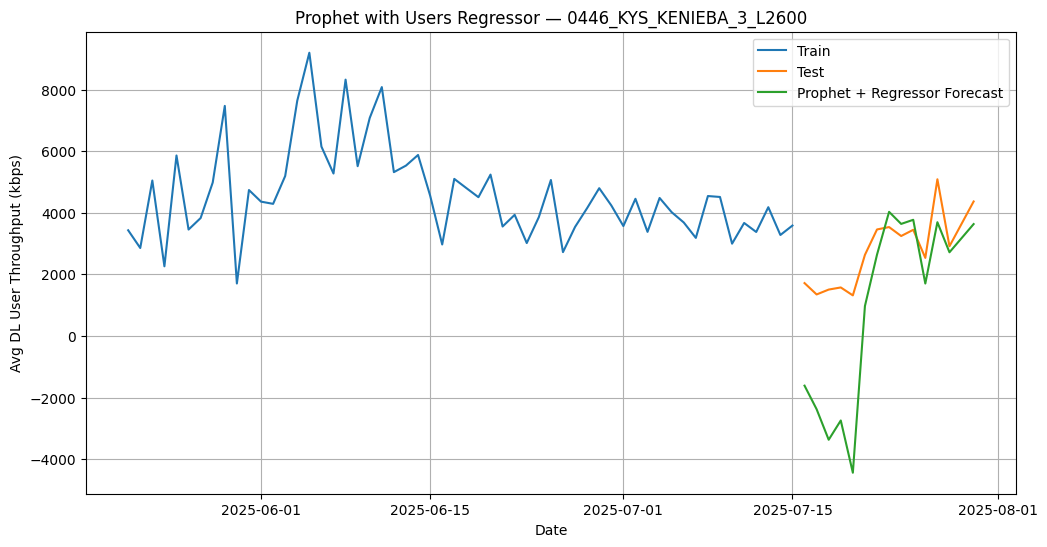

In [36]:
evaluate_prophet_with_regressor_thrpt(df, '4262_KYS_KENIEBA_3_L800')
evaluate_prophet_with_regressor_thrpt(df, '5001_KKO_DEGUEDOUMOU_3_L1800')
evaluate_prophet_with_regressor_thrpt(df, '0446_KYS_KENIEBA_3_L2600')

### Smoothing the Traffic Active Users

In [37]:
def evaluate_prophet_with_regressor_thrpt2(df, cell_name, test_ratio=0.2, return_forecast=False):
    # Filter the cell and keep both KPIs
    df_cell = df[df['Cell_Name'] == cell_name][['Date', 'Avg_DL_User_Thrput_kbps', 'Avg_DL_Traffic_Active_User']].copy()
    df_cell.rename(columns={
        'Date': 'ds',
        'Avg_DL_User_Thrput_kbps': 'y',
        'Avg_DL_Traffic_Active_User': 'users'
    }, inplace=True)
    df_cell = df_cell.sort_values('ds')

    # Smooth the regressor (KPI 2)
    df_cell['users'] = df_cell['users'].rolling(window=5, center=True, min_periods=1).median()

    # Train/test split
    split_index = int(len(df_cell) * (1 - test_ratio))
    train_df = df_cell.iloc[:split_index]
    test_df = df_cell.iloc[split_index:]

    # Prophet with regressor
    model = Prophet()
    model.add_regressor('users')
    model.fit(train_df)

    # Forecast: build future dataframe and include future regressor values
    future = df_cell[['ds', 'users']]  # reuse full dataframe (including future regressor)
    forecast = model.predict(future)

    # Align forecast with actual test set
    test_df = test_df.reset_index(drop=True)
    forecast_test = forecast[['ds', 'yhat']].merge(test_df[['ds', 'y']], on='ds', how='inner')

    # Evaluation
    mae = mean_absolute_error(forecast_test['y'], forecast_test['yhat'])
    rmse = np.sqrt(mean_squared_error(forecast_test['y'], forecast_test['yhat']))
    mape = np.mean(np.abs((forecast_test['y'] - forecast_test['yhat']) / forecast_test['y'])) * 100

    print(f"\nProphet + Regressor Evaluation for {cell_name}")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(train_df['ds'], train_df['y'], label='Train')
    plt.plot(test_df['ds'], test_df['y'], label='Test')
    plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Prophet + Regressor Forecast')
    plt.title(f'Prophet with Users Regressor — {cell_name}')
    plt.xlabel('Date')
    plt.ylabel('Avg DL User Throughput (kbps)')
    plt.legend()
    plt.grid(True)
    plt.show()

    if return_forecast:
        return forecast_test[['ds', 'yhat']].assign(cell=cell_name)

15:06:41 - cmdstanpy - INFO - Chain [1] start processing
15:06:41 - cmdstanpy - INFO - Chain [1] done processing



Prophet + Regressor Evaluation for 4262_KYS_KENIEBA_3_L800
MAE:  1021.17
RMSE: 1121.77
MAPE: 66.86%


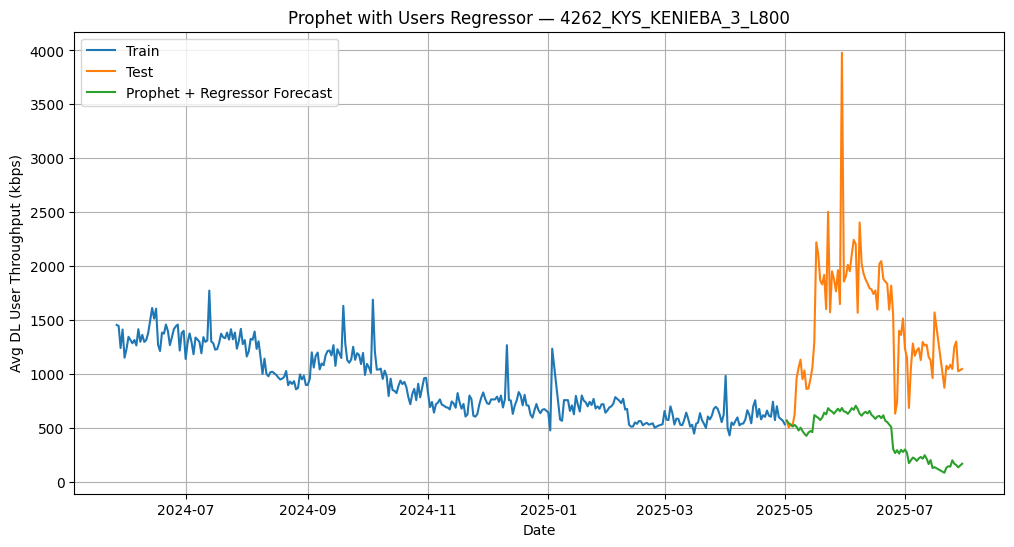

15:06:43 - cmdstanpy - INFO - Chain [1] start processing
15:06:43 - cmdstanpy - INFO - Chain [1] done processing



Prophet + Regressor Evaluation for 5001_KKO_DEGUEDOUMOU_3_L1800
MAE:  845.76
RMSE: 1062.44
MAPE: 28.03%


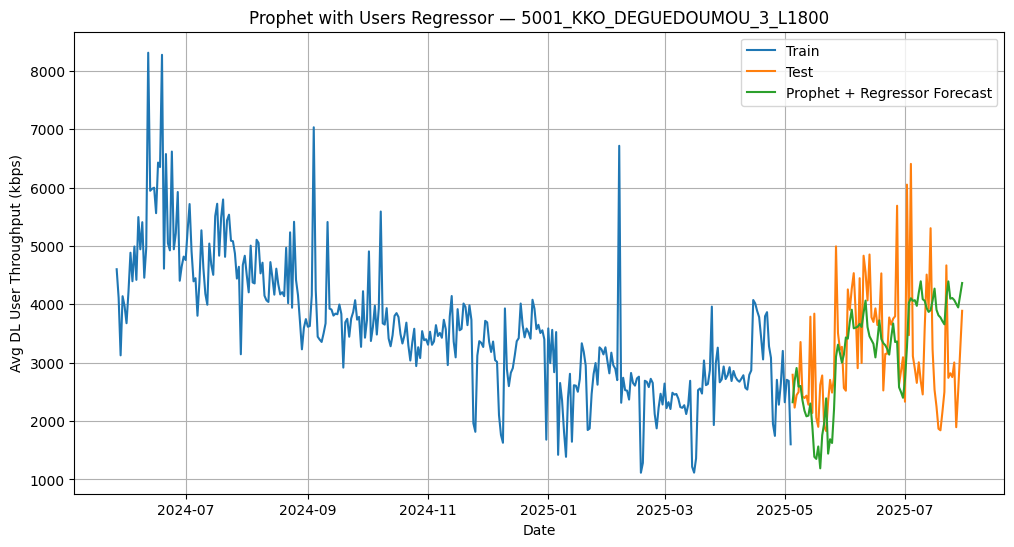

15:06:44 - cmdstanpy - INFO - Chain [1] start processing
15:06:44 - cmdstanpy - INFO - Chain [1] done processing



Prophet + Regressor Evaluation for 0446_KYS_KENIEBA_3_L2600
MAE:  9598.70
RMSE: 14354.08
MAPE: 610.52%


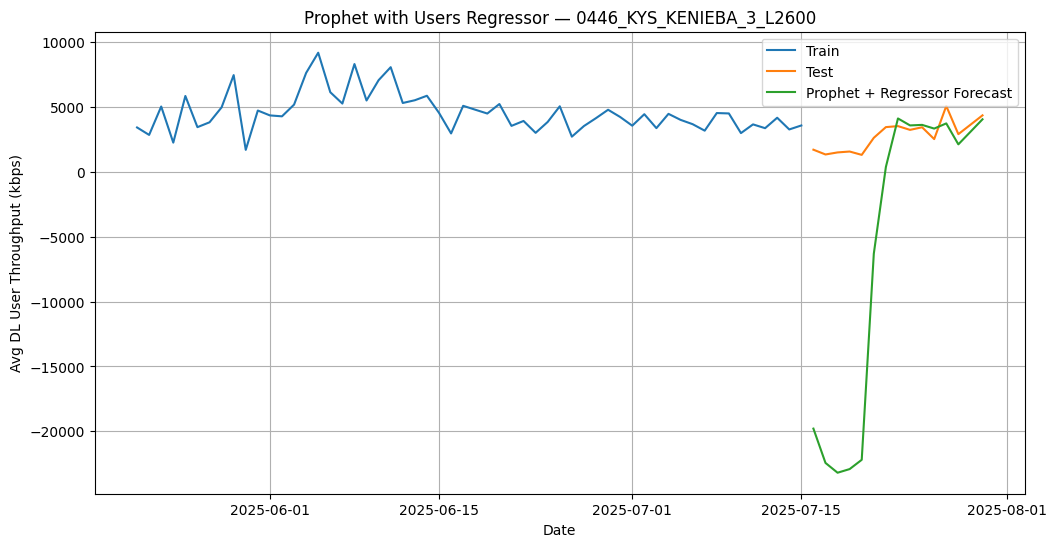

In [38]:
evaluate_prophet_with_regressor_thrpt2(df, '4262_KYS_KENIEBA_3_L800')
evaluate_prophet_with_regressor_thrpt2(df, '5001_KKO_DEGUEDOUMOU_3_L1800')
evaluate_prophet_with_regressor_thrpt2(df, '0446_KYS_KENIEBA_3_L2600')